# Walkthrough

The pipeline (`python -m clv run`) does all the work and writes its results to `outputs/`. This notebook reads those results so you can look around, check a single customer, and re-run the budget plan with your own assumptions without touching the code.

The write up with every chart is in [REPORT.md](../REPORT.md). This is the place to poke at it.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from clv import decide
from clv.config import load_config

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
T = ROOT / "outputs" / "tables"
F = ROOT / "outputs" / "figures"
cfg = load_config()

## 1. What the cleaning took out

Each row is charged to the first rule that catches it. For reversed orders the value is the orders that were cancelled, because a sale and its cancellation net to zero.

In [2]:
audit = pd.read_csv(T / "clean_audit.csv")
audit.style.format({"rows_removed": "{:,}", "rows_left": "{:,}", "value_removed": "£{:,.0f}"}).hide(axis="index")

step,rows_removed,rows_left,value_removed,note
raw rows,0,"1,067,371",£0,both sheets stacked
sheet overlap,"22,523","1,044,848","£377,488",invoice already present in the earlier sheet
exact duplicate line,"11,812","1,033,036","£54,228",identical in every column
bad debt adjustment,6,"1,033,030","£-147,614",invoice starts with A
non-product code,"5,812","1,027,218","£75,712","postage, fees, discounts, manual, samples, tests"
zero or negative price,"5,964","1,021,254",£0,sale lines with price <= 0
stock adjustment,0,"1,021,254",£0,quantity <= 0 on a non cancellation invoice
missing customer id,"227,089","794,165","£2,568,806",guest or unrecorded customer
reversed order (sale + its cancellation),"11,912","782,253","£545,622","5,956 cancellations matched, GBP 545,622 of orders undone"
unmatched cancellation (kept as return),"11,630","770,623","£-164,331",partial returns or orders from before Dec 2009


## 2. Retention

First month retention for each cohort of new customers, and the same customers eleven to thirteen months later. The autumn cohorts are the ones to look at: low through the next spring and summer, then back when the next autumn comes.

In [3]:
coh = pd.read_csv(T / "diagnose_cohorts.csv")
coh = coh[~coh["is_existing_base"]]
view = coh.pivot(index="cohort", columns="age", values="retention")
cols = [c for c in [1, 2, 3, 6, 9, 11, 12, 13] if c in view.columns]
view[cols].style.format("{:.0%}", na_rep="").background_gradient(cmap="Blues", axis=None)

age,1,2,3,6,9,11,12,13
cohort,,,,,,,,
2010-01,21%,32%,32%,27%,33%,17%,23%,18%
2010-02,24%,23%,29%,19%,28%,13%,15%,18%
2010-03,19%,23%,24%,24%,11%,15%,20%,16%
2010-04,19%,19%,16%,28%,11%,14%,14%,16%
2010-05,15%,17%,18%,21%,8%,13%,15%,15%
2010-06,18%,19%,21%,13%,11%,14%,15%,12%
2010-07,16%,18%,30%,11%,11%,15%,13%,13%
2010-08,20%,29%,33%,10%,12%,12%,15%,17%
2010-09,23%,23%,13%,14%,13%,10%,23%,17%


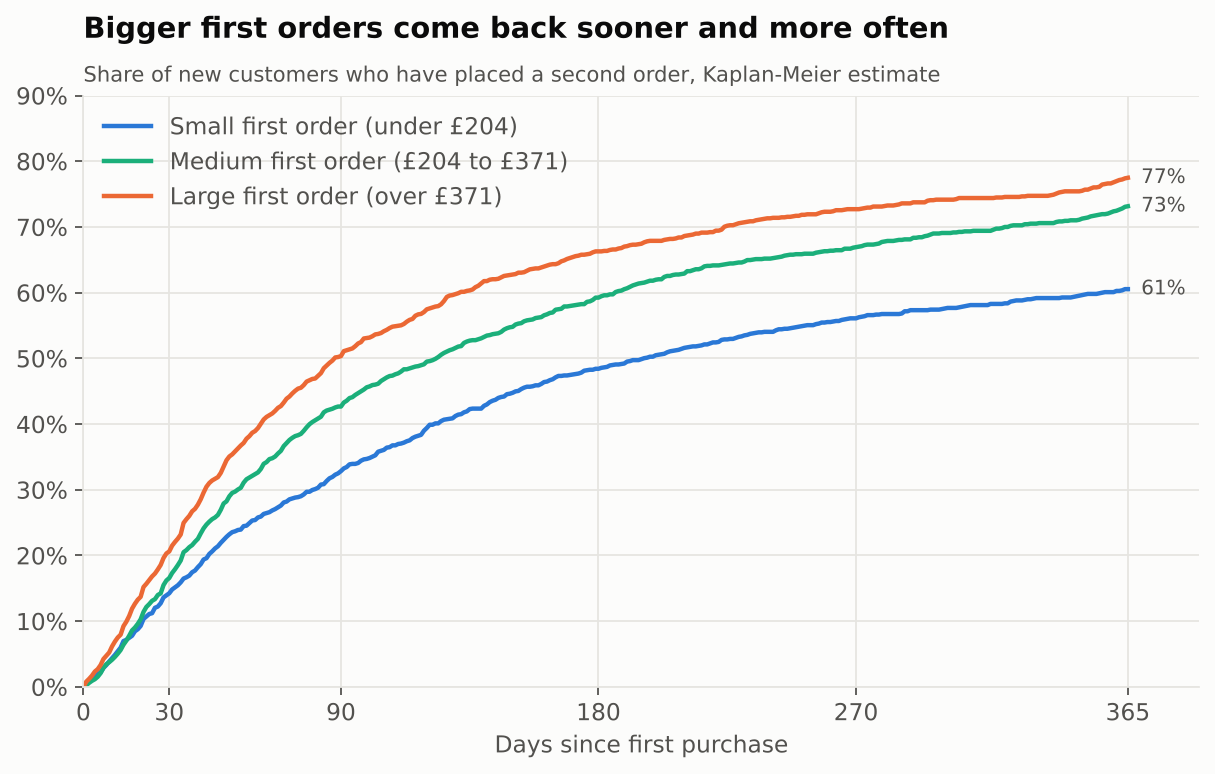

In [4]:
display(Image(F / "03_second_purchase.png", width=720))

## 3. One customer, start to finish

`explain()` puts a customer's history next to what the model and the plan say about them. Try any id from `outputs/powerbi/dim_customer.csv`.

In [5]:
cust = pd.read_csv(ROOT / "outputs" / "powerbi" / "dim_customer.csv", dtype={"Customer ID": str}).set_index("Customer ID")
inv = pd.read_csv(ROOT / "outputs" / "powerbi" / "fact_invoice.csv", dtype={"Customer ID": str}, parse_dates=["Date"])

def explain(customer_id: str) -> None:
    c = cust.loc[customer_id]
    h = inv[inv["Customer ID"] == customer_id]
    by_q = h.groupby(h["Date"].dt.to_period("Q"))["Revenue"].sum()
    print(f"Customer {customer_id}, {c['Country']}, segment {c['Segment']} (RFM {c['RFM Code']})")
    print(f"  first order {c['First Purchase']}, last order {c['Last Purchase']} ({c['Days Since Last Purchase']} day{'s' if c['Days Since Last Purchase'] != 1 else ''} before the data ends)")
    print(f"  {c['Purchase Days']} purchase days, £{c['Revenue 2 Years']:,.0f} over two years")
    print(f"  chance still active {c['P Alive']:.0%}, expected {c['Expected Purchases 26w']:.1f} orders of about £{c['Expected Order Value']:,.0f} in the next 26 weeks")
    print(f"  model value £{c['Model Value 26w']:,.0f}, planning value £{c['Planning Value 26w']:,.0f}, value rank {c['Value Rank']:,}")
    if c["In Target List"] == "Yes":
        print(f"  plan: spend £{c['Recommended Spend']:,.0f} on '{c['Recommended Action']}', for about £{c['Expected Extra Revenue']:,.0f} of extra revenue")
    else:
        print("  plan: no paid action")
    print("\nRevenue by quarter:")
    print(by_q.map("£{:,.0f}".format).to_string())

explain(cust.sort_values("Value Rank").index[0])

Customer 18102, United Kingdom, segment Champions (RFM 555)
  first order 2009-12-01, last order 2011-12-09 (1 day before the data ends)
  67 purchase days, £579,129 over two years
  chance still active 100%, expected 13.3 orders of about £8,593 in the next 26 weeks
  model value £114,365, planning value £75,705, value rank 1
  plan: spend £104 on 'Early access to new ranges, account manager check-in', for about £4,502 of extra revenue

Revenue by quarter:
Date
2009Q4    £40,430
2010Q1    £83,790
2010Q2    £45,120
2010Q3    £97,843
2010Q4    £80,123
2011Q1    £17,445
2011Q2    £61,322
2011Q3    £73,558
2011Q4    £79,498
Freq: Q-DEC


In [6]:
# a large account that has gone quiet
quiet = cust[(cust["Segment"] == "Can't lose them") & (cust["In Target List"] == "Yes")]
explain(quiet.sort_values("Expected Extra Revenue", ascending=False).index[0])

Customer 13902, Denmark, segment Can't lose them (RFM 145)
  first order 2009-12-15, last order 2010-03-17 (633 days before the data ends)
  5 purchase days, £30,392 over two years
  chance still active 2%, expected 0.0 orders of about £5,883 in the next 26 weeks
  model value £93, planning value £62, value rank 4,576
  plan: spend £52 on 'Senior account manager call, tailored offer, find out what changed', for about £489 of extra revenue

Revenue by quarter:
Date
2009Q4       £358
2010Q1    £30,035
Freq: Q-DEC


## 4. How the model did on data it never saw

In [7]:
bt = pd.read_csv(T / "predict_backtest.csv")
bt = bt[bt["target"] == "revenue"][["fold", "method", "predicted_total", "actual_total", "total_error_pct", "spearman", "top10_capture"]]
bt.style.format({"predicted_total": "£{:,.0f}", "actual_total": "£{:,.0f}", "total_error_pct": "{:+.0%}",
                 "spearman": "{:.2f}", "top10_capture": "{:.0%}"}).hide(axis="index")

fold,method,predicted_total,actual_total,total_error_pct,spearman,top10_capture
Jun to Dec 2011 (busy season),"MBG/NBD + Gamma-Gamma, seasonal clock","£4,048,732","£4,270,727",-5%,0.63,63%
Jun to Dec 2011 (busy season),"BG/NBD + Gamma-Gamma, seasonal clock","£4,051,009","£4,270,727",-5%,0.63,63%
Jun to Dec 2011 (busy season),"BG/NBD + Gamma-Gamma, calendar clock","£3,570,313","£4,270,727",-16%,0.63,64%
Jun to Dec 2011 (busy season),"MBG/NBD + Gamma-Gamma, calendar clock","£3,569,849","£4,270,727",-16%,0.63,63%
Jun to Dec 2011 (busy season),Same as last 26 weeks,"£3,051,798","£4,270,727",-29%,0.57,62%
Jun to Dec 2011 (busy season),Historical average rate,"£6,811,951","£4,270,727",+60%,0.58,60%
Dec 2010 to Jun 2011 (quiet season),"MBG/NBD + Gamma-Gamma, seasonal clock","£3,910,764","£2,588,777",+51%,0.55,61%
Dec 2010 to Jun 2011 (quiet season),"BG/NBD + Gamma-Gamma, seasonal clock","£3,904,915","£2,588,777",+51%,0.55,61%
Dec 2010 to Jun 2011 (quiet season),"BG/NBD + Gamma-Gamma, calendar clock","£4,362,327","£2,588,777",+69%,0.54,61%
Dec 2010 to Jun 2011 (quiet season),"MBG/NBD + Gamma-Gamma, calendar clock","£4,366,048","£2,588,777",+69%,0.54,61%


## 5. Re-run the budget plan with your own assumptions

The plan in the report uses the base case from `config.toml`. Change the numbers below and run the cell. This re-optimises on the saved customer values, so it takes a second.

In [8]:
values = pd.read_csv(T / "predict_customer_values.csv", dtype={"customer_id": str}).set_index("customer_id")
frame = values[["planning_value", "expected_value", "p_alive", "revenue", "repeat_purchases"]].copy()
frame["segment"] = cust["Segment"].reindex(frame.index)
p = frame["p_alive"].clip(lower=0.01)
frame["value_at_risk"] = frame["planning_value"] * (1 - p) / p

def plan(budget=50_000, margin=0.35, lift=0.06, recovery=0.15, spend_scale=25):
    a = {"lift": lift, "recovery": recovery, "k": spend_scale, "margin": margin}
    M = decide.max_lift(frame, a)
    x = decide.optimal_spend(M, a["k"], a["margin"], budget)
    o = decide.outcome(x, M, a["k"], a["margin"])
    seg = decide.by_segment(frame, x, o["inc"], margin)
    seg = seg[seg["spend"] > 0][["segment", "targeted", "customers", "spend", "incremental_revenue", "roi"]]
    print(f"Spend £{o['spend']:,.0f} of £{budget:,.0f} on {int((x > 0).sum()):,} accounts, "
          f"£{o['incremental_revenue']:,.0f} extra revenue, £{o['incremental_profit']:,.0f} profit after spend")
    return seg.style.format({"spend": "£{:,.0f}", "incremental_revenue": "£{:,.0f}", "roi": "{:.2f}"}).hide(axis="index")

plan()

Spend £6,315 of £50,000 on 394 accounts, £53,588 extra revenue, £12,441 profit after spend


segment,targeted,customers,spend,incremental_revenue,roi
Champions,249,868,"£4,295","£41,852",2.41
Loyal,117,1270,"£1,625","£9,602",1.07
Potential loyalists,2,677,£9,£27,0.09
At risk,3,859,£41,£284,1.40
Can't lose them,23,103,£344,"£1,823",0.85


In [9]:
# what if a campaign works twice as well as I assumed, and costs less per account?
plan(lift=0.12, recovery=0.25, spend_scale=15)

Spend £21,299 of £50,000 on 1,871 accounts, £187,887 extra revenue, £44,461 profit after spend


segment,targeted,customers,spend,incremental_revenue,roi
Champions,709,868,"£11,224","£126,546",2.95
Loyal,739,1270,"£7,556","£48,425",1.24
Potential loyalists,194,677,£909,"£3,500",0.35
New,19,25,£31,£94,0.07
Need attention,27,500,£87,£297,0.20
At risk,101,859,£437,"£2,093",0.68
Can't lose them,82,103,"£1,056","£6,931",1.30
